Data Awal:


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


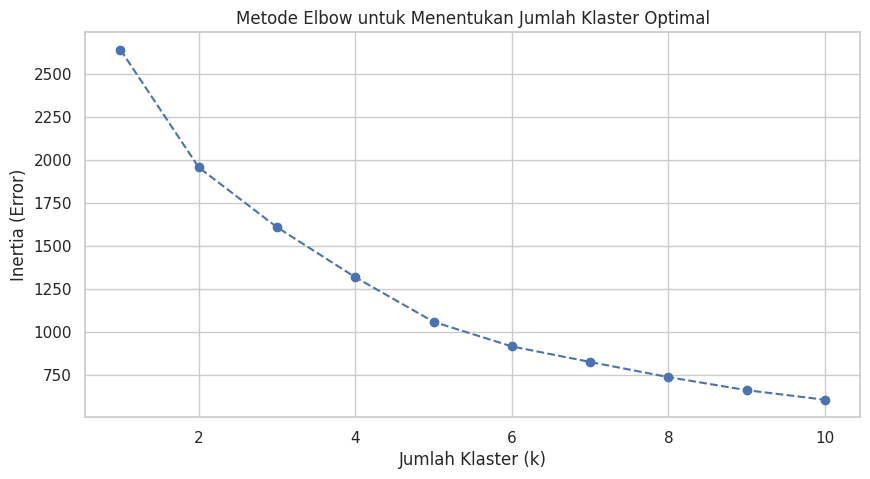


=== Profil Rata-rata Belanja per Klaster ===


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Cluster,,,,,,
0,10440.93,19386.42,28656.09,2190.24,13327.80,2374.20
1,12062.91,4115.10,5534.97,2940.68,1696.17,1299.11
2,34782.00,30367.00,16898.00,48701.50,755.50,26776.00



=== Jumlah Pelanggan per Klaster ===
Cluster
1    393
0     45
2      2
Name: count, dtype: int64


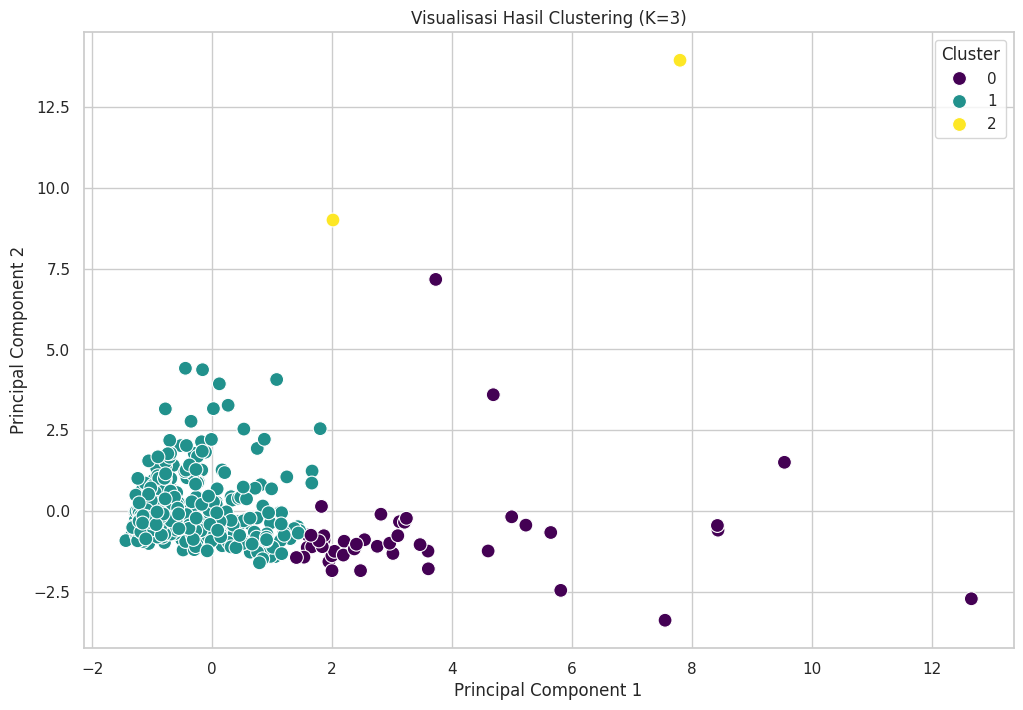

In [2]:
# ==========================================
# BAGIAN 1: IMPORT LIBRARY & DATA
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Mengatur gaya visualisasi agar terlihat profesional di video
sns.set(style="whitegrid")

# Load dataset
# Pastikan file 'Wholesale customers data.csv' sudah di-upload
df = pd.read_csv('Wholesale customers data.csv')

# Menampilkan 5 baris pertama untuk pemeriksaan awal
print("Data Awal:")
display(df.head())

# ==========================================
# BAGIAN 2: PREPROCESSING (PEMBERSIHAN DATA)
# ==========================================

# Hanya mengambil kolom belanja (Drop Channel & Region)
# Channel & Region adalah data kategori, tidak cocok untuk jarak Euclidean jika tidak dipisah
features = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
X = df[features]

# SCALING / STANDARISASI (Sangat Penting!)
# Mengubah angka rupiah/dolar menjadi skala standar (Z-Score)
# Agar angka besar (seperti 50.000) tidak mendominasi angka kecil
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==========================================
# BAGIAN 3: MENENTUKAN JUMLAH KLASTER (ELBOW METHOD)
# ==========================================

inertia = []
K_range = range(1, 11)

# Melakukan looping untuk mencoba K dari 1 sampai 10
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Visualisasi Elbow Method
plt.figure(figsize=(10, 5))
plt.plot(K_range, inertia, marker='o', linestyle='--', color='b')
plt.title('Metode Elbow untuk Menentukan Jumlah Klaster Optimal')
plt.xlabel('Jumlah Klaster (k)')
plt.ylabel('Inertia (Error)')
plt.show()

# ==========================================
# BAGIAN 4: MODELING (CLUSTERING)
# ==========================================

# Kita pilih K=3 berdasarkan Elbow Method
k_optimal = 3
kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Menyimpan hasil klaster ke dataframe asli
df['Cluster'] = clusters

# ==========================================
# BAGIAN 5: EVALUASI & PROFILING
# ==========================================

# Menghitung rata-rata belanja tiap klaster untuk interpretasi
print("\n=== Profil Rata-rata Belanja per Klaster ===")
profil_klaster = df.groupby('Cluster')[features].mean()
display(profil_klaster.round(2))

print("\n=== Jumlah Pelanggan per Klaster ===")
print(df['Cluster'].value_counts())

# ==========================================
# BAGIAN 6: VISUALISASI HASIL (PCA)
# ==========================================
# Karena datanya 6 dimensi, kita perkecil jadi 2 dimensi pakai PCA agar bisa digambar

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['Cluster'], palette='viridis', s=100)

plt.title(f'Visualisasi Hasil Clustering (K={k_optimal})')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()